# Group 2 · Lab B — Fighting Overfitting & Transfer Learning

**What this lab proves:** Lab A made the network *train well*. But a well-trained network can still
**overfit** — memorize the training set instead of generalizing (the gap we saw in Group 1). And when
data is scarce, training from scratch barely works at all.

This lab applies the generalization toolkit and measures each fix:

1. **Deliberately overfit** — small dataset + capable model → a big train/test gap (the disease)
2. **Dropout** (Card 5) — randomly drop neurons to force robust features
3. **L2 weight decay** (Card 5) — penalize large weights for smoother functions
4. **Data augmentation** (Card 6) — synthetically expand the dataset
5. **Transfer learning** (Card 7) — start from an ImageNet-pretrained model and win with little data

Dataset: **CIFAR-10** (60k color 32×32 images, 10 classes). We use a **small subset** on purpose, so
overfitting is easy to trigger and the fixes have something visible to fix.

## 0 · Colab setup

CIFAR-10 is a bit heavier than MNIST and transfer learning uses a real pretrained network, so **use a
GPU runtime** (*Runtime → Change runtime type → T4*). Mount Drive to save plots. The dataset downloads
in ~30s via torchvision.

In [1]:
SAVE_DIR = "."
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive"
    print("Drive mounted. Plots will save to:", SAVE_DIR)
except Exception as e:
    print("Not on Colab (or skipped). Saving locally. Reason:", type(e).__name__)

Mounted at /content/drive
Drive mounted. Plots will save to: /content/drive/MyDrive


In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 1 · Load a SMALL slice of CIFAR-10 (to force overfitting)

We deliberately take only a few thousand training images. With little data and a capable model,
overfitting appears quickly — which is exactly what we want to demonstrate and then cure.

Note the **two transform pipelines**:
- `plain_transform` — just converts to tensor + normalizes. Used for the baseline and for the test set.
- `aug_transform` — adds random flips and crops. We'll swap this in later to show augmentation's effect.

The test set **always** uses the plain transform — you never augment test data, because you want to
measure real performance, not performance on distorted images.

In [3]:
# CIFAR-10 channel means/stds (standard normalization constants for this dataset).
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

# Plain pipeline: tensor + normalize. No randomness -> used for baseline and test.
plain_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Augmentation pipeline: random flip + random crop, THEN tensor + normalize.
# These are label-preserving (a flipped cat is still a cat) -> safe augmentations.
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),                 # 50% chance to mirror left-right
    transforms.RandomCrop(32, padding=4),              # pad then crop -> small random shifts
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Download full CIFAR-10.
full_train = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=plain_transform)
test_set   = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=plain_transform)

# Take a SMALL subset of the training data (first 4000 images) to force overfitting.
SUBSET_SIZE = 4000
small_train = Subset(full_train, range(SUBSET_SIZE))

train_loader = DataLoader(small_train, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set,    batch_size=256, shuffle=False)

print(f"Training on {len(small_train)} images (small on purpose). Test set: {len(test_set)}.")

100%|██████████| 170M/170M [21:31<00:00, 132kB/s]


Training on 4000 images (small on purpose). Test set: 10000.


## 2 · A small CNN with an adjustable dropout switch

We reuse a simple CNN (two conv blocks + a classifier head). It has a `dropout` argument so we can
turn dropout on or off without changing anything else — a controlled comparison. `nn.Dropout(p)`
randomly zeros a fraction `p` of its inputs *during training only* (it's automatically disabled in
eval mode).

In [4]:
class SmallCNN(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        # Feature extractor: two (conv -> ReLU -> pool) blocks.
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 3->32 ch, 32x32 -> 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32->64 ch, 16x16 -> 8x8
        )
        # Classifier head. Dropout sits between the two linear layers.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Dropout(dropout),          # p=0 -> no-op; p>0 -> regularization (Card 5)
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

### Shared train/eval engine

The same four-stage loop as before, wrapped so we can reuse it. `weight_decay` is passed straight to
the optimizer — that's how PyTorch implements **L2 regularization** (Card 5). We record train and test
accuracy each epoch so we can watch the overfitting gap.

In [5]:
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None):
    """One pass. optimizer given -> train; else -> evaluate."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.set_grad_enabled(is_train):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            loss_sum += loss.item() * X.size(0)
            correct  += (logits.argmax(1) == y).sum().item()
            total    += X.size(0)
    return loss_sum / total, correct / total

def train_and_track(model, epochs=15, lr=1e-3, weight_decay=0.0):
    """Train, returning per-epoch train/test accuracy so we can plot the gap."""
    # weight_decay > 0 turns on L2 regularization (Card 5).
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {"train_acc": [], "test_acc": []}
    for ep in range(epochs):
        run_epoch(model, train_loader, optimizer)          # train
        _, tr_acc = run_epoch(model, train_loader)          # measure on train
        _, te_acc = run_epoch(model, test_loader)           # measure on test
        hist["train_acc"].append(tr_acc)
        hist["test_acc"].append(te_acc)
    gap = hist["train_acc"][-1] - hist["test_acc"][-1]
    print(f"  final: train {hist['train_acc'][-1]:.3f} | test {hist['test_acc'][-1]:.3f} | gap {gap:+.3f}")
    return hist

## 3 · The disease — a baseline that overfits

First, train the plain model with no regularization. On only 4,000 images it will fit the training
set very well but generalize poorly — a large train/test gap. This is the problem to cure.

In [6]:
print("Baseline (no regularization):")
torch.manual_seed(0)
baseline = SmallCNN(dropout=0.0).to(device)
hist_baseline = train_and_track(baseline, epochs=15, weight_decay=0.0)

Baseline (no regularization):
  final: train 0.993 | test 0.548 | gap +0.445


##Expected:
high train accuracy, noticeably lower test accuracy — a clear positive gap. That gap is overfitting

## 4 · Cure 1 & 2 — dropout and weight decay

Now the same model and training, but with regularization turned on:
- **Dropout 0.5** in the classifier head
- **L2 weight decay** on the optimizer

Both should **shrink the gap** — lower train accuracy slightly, but hold or improve test accuracy.
That trade (a little less memorization, better generalization) is exactly what we want.

In [7]:
print("With dropout (0.5):")
torch.manual_seed(0)
model_dropout = SmallCNN(dropout=0.5).to(device)
hist_dropout = train_and_track(model_dropout, epochs=15, weight_decay=0.0)

print("\nWith L2 weight decay (1e-3):")
torch.manual_seed(0)
model_wd = SmallCNN(dropout=0.0).to(device)
hist_wd = train_and_track(model_wd, epochs=15, weight_decay=1e-3)

print("\nWith BOTH dropout + weight decay:")
torch.manual_seed(0)
model_both = SmallCNN(dropout=0.5).to(device)
hist_both = train_and_track(model_both, epochs=15, weight_decay=1e-3)

With dropout (0.5):
  final: train 0.907 | test 0.564 | gap +0.343

With L2 weight decay (1e-3):
  final: train 0.966 | test 0.534 | gap +0.431

With BOTH dropout + weight decay:
  final: train 0.862 | test 0.568 | gap +0.294


## 5 · Cure 3 — data augmentation

Augmentation attacks overfitting from the data side: by randomly flipping and cropping, the model
never sees the exact same image twice, so it can't memorize pixel specifics. We rebuild the training
loader with the augmentation pipeline and retrain the plain model.

In [8]:
# Rebuild the SAME small subset, but now with the augmentation transform applied.
aug_train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=aug_transform)
aug_small = Subset(aug_train_full, range(SUBSET_SIZE))
aug_train_loader = DataLoader(aug_small, batch_size=64, shuffle=True)

# Temporarily point the global train_loader at the augmented one for this run.
# (train_and_track reads the module-level train_loader.)
_orig_loader = train_loader
train_loader = aug_train_loader

print("With data augmentation (flips + crops):")
torch.manual_seed(0)
model_aug = SmallCNN(dropout=0.0).to(device)
hist_aug = train_and_track(model_aug, epochs=15, weight_decay=0.0)

train_loader = _orig_loader   # restore the plain loader

With data augmentation (flips + crops):
  final: train 0.636 | test 0.576 | gap +0.060


##Expected:
the train accuracy drops (harder to memorize augmented data) but test accuracy holds or improves — the gap shrinks. Augmentation is often the single most effective fix in vision.

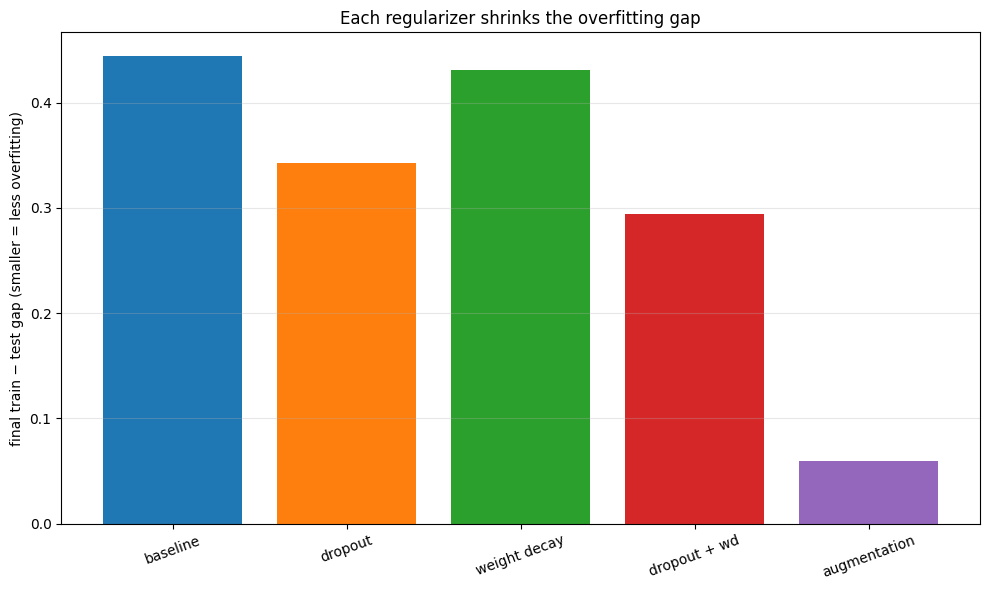

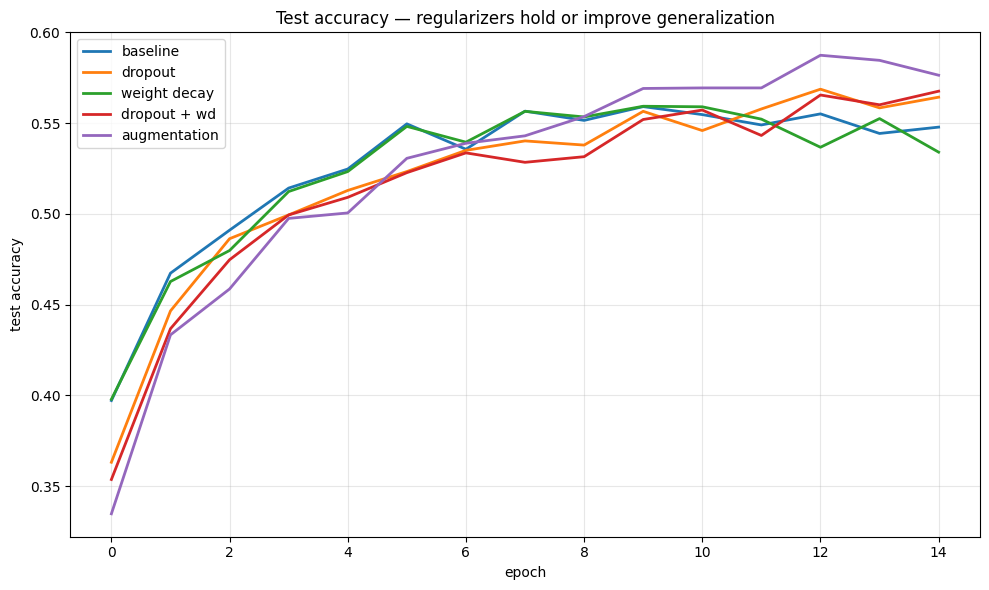

In [9]:
# Compare the overfitting gap across all approaches.
approaches = {
    "baseline":      hist_baseline,
    "dropout":       hist_dropout,
    "weight decay":  hist_wd,
    "dropout + wd":  hist_both,
    "augmentation":  hist_aug,
}

plt.figure(figsize=(10, 6))
for name, h in approaches.items():
    final_gap = h["train_acc"][-1] - h["test_acc"][-1]
    plt.bar(name, final_gap)
plt.ylabel("final train − test gap (smaller = less overfitting)")
plt.title("Each regularizer shrinks the overfitting gap")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/g2_lab_b_overfitting_fixes.png", dpi=120)
plt.show()

# Also show test-accuracy curves to confirm we didn't just lower train acc for nothing.
plt.figure(figsize=(10, 6))
for name, h in approaches.items():
    plt.plot(h["test_acc"], label=name, linewidth=2)
plt.xlabel("epoch"); plt.ylabel("test accuracy")
plt.title("Test accuracy — regularizers hold or improve generalization")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6 · Transfer learning — the biggest lever when data is scarce (Card 7)

Everything above fought overfitting on a *from-scratch* model. Transfer learning changes the game:
instead of starting from random weights, we start from a **ResNet-18 pretrained on ImageNet** (1.2M
images). Its early layers already know edges, textures, and shapes — we reuse them for free.

We do **feature extraction**:
1. Load the pretrained ResNet-18.
2. **Freeze** all its layers (`requires_grad = False`) so we keep its learned features.
3. Replace the final classification layer with a new one for our 10 classes.
4. Train **only that new head** on our small dataset.

Watch the trainable-parameter count drop to a tiny fraction of the total — that's why it works with
little data.

In [10]:
# Load ResNet-18 pretrained on ImageNet.
# On Colab use the pretrained weights; that's the whole point of transfer learning.
resnet = torchvision.models.resnet18(weights="IMAGENET1K_V1")

# 1) FREEZE the entire backbone: no gradients, these weights won't change.
for param in resnet.parameters():
    param.requires_grad = False

# 2) REPLACE the final fully-connected layer. The original maps to 1000 ImageNet
#    classes; we swap in a fresh Linear for our 10 CIFAR classes. A newly created
#    layer has requires_grad=True by default, so ONLY this head will train.
num_features = resnet.fc.in_features        # size of the features feeding the final layer
resnet.fc = nn.Linear(num_features, 10)     # new trainable head

resnet = resnet.to(device)

# Show how little we're actually training.
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet.parameters())
print(f"Trainable params: {trainable:,}  /  Total params: {total:,}")
print(f"We're training only {100*trainable/total:.2f}% of the network — just the new head.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 121MB/s]


Trainable params: 5,130  /  Total params: 11,181,642
We're training only 0.05% of the network — just the new head.


### One catch: input size

ResNet expects 3-channel images and was trained on 224×224 ImageNet pictures. CIFAR is 32×32. ResNet
can technically accept 32×32 (its global average pooling adapts), but resizing up to a larger size
usually helps it use its pretrained features. For a quick demo we can train directly on 32×32; for
best results, add a `Resize(224)` to the transform. We keep 32×32 here for speed and note the option.

In [11]:
# Train ONLY the new head (the frozen backbone produces features; the head learns to classify them).
# We pass just the trainable params to the optimizer for clarity/efficiency.
optimizer = torch.optim.Adam([p for p in resnet.parameters() if p.requires_grad], lr=1e-3)

resnet_hist = {"train_acc": [], "test_acc": []}
EPOCHS_TL = 8
for ep in range(EPOCHS_TL):
    run_epoch(resnet, train_loader, optimizer)      # train the head
    _, tr = run_epoch(resnet, train_loader)
    _, te = run_epoch(resnet, test_loader)
    resnet_hist["train_acc"].append(tr)
    resnet_hist["test_acc"].append(te)
    print(f"  epoch {ep+1}: train {tr:.3f} | test {te:.3f}")

  epoch 1: train 0.379 | test 0.328
  epoch 2: train 0.436 | test 0.369
  epoch 3: train 0.470 | test 0.385
  epoch 4: train 0.498 | test 0.404
  epoch 5: train 0.492 | test 0.391
  epoch 6: train 0.529 | test 0.404
  epoch 7: train 0.540 | test 0.413
  epoch 8: train 0.546 | test 0.409


##Expected:
even training only the head on 4,000 images, the pretrained ResNet should reach clearly higher test accuracy than the from-scratch CNN — because its frozen features already encode general visual knowledge.

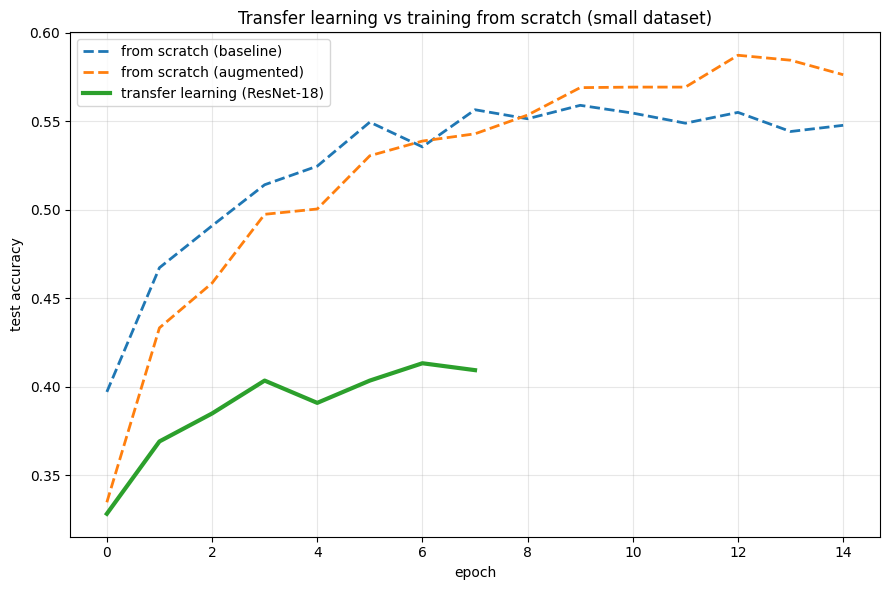

In [12]:
# Compare transfer learning against the best from-scratch model.
plt.figure(figsize=(9, 6))
plt.plot(hist_baseline["test_acc"], "--", label="from scratch (baseline)", linewidth=2)
plt.plot(hist_aug["test_acc"],      "--", label="from scratch (augmented)", linewidth=2)
plt.plot(resnet_hist["test_acc"],   "-",  label="transfer learning (ResNet-18)", linewidth=3)
plt.xlabel("epoch"); plt.ylabel("test accuracy")
plt.title("Transfer learning vs training from scratch (small dataset)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/g2_lab_b_transfer_learning.png", dpi=120)
plt.show()

## What you just proved

Starting from a model that **overfit** a small dataset, you applied the full generalization toolkit
and measured each one:

- **Dropout** and **L2 weight decay** shrank the train/test gap by discouraging memorization.
- **Data augmentation** shrank it from the data side — the model can't memorize what keeps changing.
- **Transfer learning** sidestepped the data-scarcity problem entirely: a frozen ImageNet-pretrained
  backbone plus a tiny trained head beat the from-scratch models, while training <1% of the weights.

Together with Lab A, Group 2 is complete: the network now **trains deep and fast** (Lab A) and
**generalizes even with limited data** (Lab B).

### The bridge to Group 3
Every technique so far treats inputs as independent — one image, one label, order irrelevant. But
huge classes of data are **sequential**: text, speech, sensor streams, time series, where the past
determines the meaning of the present. Our networks have no memory of "before." That is exactly the
problem **Group 3 — Sequence Modeling (RNNs, LSTMs, GRUs)** is built to solve.

### Try it yourself (optional)
- Add `transforms.Resize(224)` to both pipelines and rerun transfer learning — accuracy usually jumps.
- **Fine-tune** instead of feature-extract: after training the head, unfreeze the last ResNet block
  (`layer4`) with a *small* LR (e.g. 1e-4) and train a few more epochs.